In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr


In [3]:
# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
from taylor_setup import *

In [7]:
# %% 1. Load the overlap archive, or use the dictionaries already in your kernel
import numpy as np
from pathlib import Path

# These contain already deseasonalized/detrended temporal SDs for 03/2000–12/2014.
# No raw climate files, new detrending, or vs_obs comparison scores are needed.
# Set False when adding these cells to a notebook where the archive is loaded.
load_variability_archive = True
variability_archive_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
if load_variability_archive:
    # These files contain pickled dictionaries; only load files you created/trust.
    overlap_member_values = np.load(variability_archive_dir / "overlap_member_values.npy", allow_pickle=True).item()
    overlap_observations = np.load(variability_archive_dir / "overlap_observations.npy", allow_pickle=True).item()
    overlap_model_names = np.load(variability_archive_dir / "overlap_model_names.npy", allow_pickle=True).item()
    overlap_coordinates = np.load(variability_archive_dir / "overlap_coordinates.npy", allow_pickle=True).item()




In [4]:
# %% 2. Average VARIANCES within members/models; take square roots only for display
def mean_and_count(values, axis=0):
    """Finite arithmetic mean and contributor count; empty locations stay NaN."""
    finite = np.isfinite(values)
    count = finite.sum(axis=axis)
    total = np.where(finite, values, 0.).sum(axis=axis)
    mean = np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0)
    return mean, count


# Keep all available familiar groups in the outputs, but plot only the matched
# historical and AMIP groups. Name matching handles different input model orders.
variability_fields = {"T": "sigma_Ti", "R": "sigma_Ri"}
variability_model_names = {e: list(overlap_model_names[e]) for e in
                         ["historical", "historical_matched", "amip_hist"] if e in overlap_member_values}
if not {"historical_matched", "amip_hist"}.issubset(variability_model_names):
    raise ValueError("Both historical_matched and amip_hist are required.")
for experiment, names in variability_model_names.items():
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: model names must be nonempty and unique.")
if set(variability_model_names["historical_matched"]) != set(variability_model_names["amip_hist"]):
    raise ValueError("Historical matched and AMIP must contain the same model names.")
variability_model_names["historical_matched"] = variability_model_names["amip_hist"].copy()

variability_lat, variability_lon = [np.asarray(overlap_coordinates[k]) for k in ["lat", "lon"]]
variability_shape = (len(variability_lat), len(variability_lon))
variability_support = np.asarray(overlap_coordinates["local_support"], dtype=bool)
if variability_support.shape != variability_shape:
    raise ValueError("The saved local_support mask must match the lat/lon grid.")

# There is no spatial averaging here: every operation is done separately at
# each grid cell. The original preprocessing and temporal-SD convention are kept.
variability_obs_variance, variability_obs_std = {}, {}
variability_model_mean_variance, variability_model_n_members = {}, {}
variability_MMM_variance, variability_MMM_rms_std, variability_MMM_n_models = {}, {}, {}
for field, quantity in variability_fields.items():
    obs_sd = np.ma.asarray(overlap_observations[quantity], dtype=float).filled(np.nan)
    if obs_sd.shape != variability_shape or np.any(obs_sd[np.isfinite(obs_sd)] < 0):
        raise ValueError(f"{quantity}: expected a nonnegative SD map on the saved grid.")
    obs_sd = np.where(variability_support & np.isfinite(obs_sd), obs_sd, np.nan)
    variability_obs_std[field], variability_obs_variance[field] = obs_sd, obs_sd**2

for experiment, names in variability_model_names.items():
    variability_model_mean_variance[experiment], variability_model_n_members[experiment] = {}, {}
    for field, quantity in variability_fields.items():
        model_variances, member_counts = [], []
        for model in names:
            # Member temporal SDs: (member, lat, lon). Square EACH member first.
            # Squaring overlap_model_means[experiment][quantity] would be wrong
            # for this estimand: those saved maps are arithmetic means of SDs.
            sd = np.ma.asarray(overlap_member_values[experiment][quantity][model], dtype=float).filled(np.nan)
            if sd.ndim != 3 or sd.shape[0] == 0 or sd.shape[1:] != variability_shape:
                raise ValueError(f"{experiment}/{model}/{quantity}: expected (member, lat, lon).")
            if np.any(sd[np.isfinite(sd)] < 0):
                raise ValueError(f"{experiment}/{model}/{quantity}: SD cannot be negative.")
            variance = np.where(variability_support & np.isfinite(sd), sd**2, np.nan)
            mean_variance, n_members = mean_and_count(variance)
            model_variances.append(mean_variance)
            member_counts.append(n_members)
        # Model-axis order is explicitly recorded in variability_model_names.
        variability_model_mean_variance[experiment][field] = np.stack(model_variances)
        variability_model_n_members[experiment][field] = np.stack(member_counts)

# By default, each displayed grid cell uses the SAME available models in matched
# historical and AMIP, plus finite observations. This only matters when data are
# missing; it prevents different local model populations from driving differences.
# Setting False instead averages available models separately in each experiment.
variability_pair_model_support = True
for experiment in variability_model_names:
    variability_MMM_variance[experiment], variability_MMM_rms_std[experiment] = {}, {}
    variability_MMM_n_models[experiment] = {}
    for field in variability_fields:
        values = variability_model_mean_variance[experiment][field]
        if variability_pair_model_support and experiment in ["historical_matched", "amip_hist"]:
            hist = variability_model_mean_variance["historical_matched"][field]
            amip = variability_model_mean_variance["amip_hist"][field]
            paired = np.isfinite(hist) & np.isfinite(amip) & np.isfinite(variability_obs_std[field])
            values = np.where(paired, values, np.nan)

        # Equal MODEL weighting, not pooled-member weighting. The square root of
        # this mean variance is the hierarchical RMS SD used in the model panels.
        mean_variance, n_models = mean_and_count(values)
        variability_MMM_variance[experiment][field] = mean_variance
        variability_MMM_rms_std[experiment][field] = np.sqrt(mean_variance)
        variability_MMM_n_models[experiment][field] = n_models

# Plot-array order: row = temperature/radiation; column = OBS/historical/AMIP.
# Observations have one SD estimate, so sqrt(observed variance) is just that SD.
variability_grid_maps = np.stack([
    np.stack([variability_obs_std[field], variability_MMM_rms_std["historical_matched"][field],
              variability_MMM_rms_std["amip_hist"][field]]) for field in variability_fields
])
print("Plot maps:", variability_grid_maps.shape, "= (field, dataset, lat, lon)")
print("Matched models:", len(variability_model_names["amip_hist"]))




Plot maps: (2, 3, 72, 144) = (field, dataset, lat, lon)
Matched models: 16


In [5]:
# %% 3. Plotting function: the relationship-grid style, now two positive-valued rows
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point


def plot_2x3_variability_maps(maps, lat, lon, *, row_titles=("Local temperature", "Local radiation"),
                            column_titles=("Observations", "Historical (matched)", "AMIP-hist"),
                            figure_title="Local variability: square root of mean temporal variance",
                            colorbar_labels=(r"Temperature SD [K]", r"Radiation SD [W m$^{-2}$]"),
                            cmaps=("YlOrRd", "YlGnBu"), vmaxs=None, robust_percentile=98,
                            number_of_levels=21, plot_method="contourf", central_longitude=210,
                            robust_masks=None, stipple_stride=2, stipple_size=3., stipple_alpha=.65,
                            stipple_color="black", figsize=(18, 8), savepath=None, dpi=200):
    """Two rows × three columns of nonnegative SD-display maps; no statistics fitted.

    One shared LINEAR 0..vmax color scale per row. vmaxs can be [T_max, R_max],
    one shared scalar, or None for automatic row limits across all three columns.
    The percentile controls display saturation only, never the variance averaging.
    plot_method is 'contourf' or 'pcolormesh'. Coordinates are 1D regular global grids.

    Optional robust_masks is a nested 2×3 list of 2D masks/None. Only finite nonzero
    mask cells with finite plotted values are stippled. No significance calculation
    is made. Do NOT reuse covariance-map robustness masks for these variance maps.
    Returns fig, axes, where axes.shape == (2, 3).
    """
    maps = np.ma.asarray(maps, dtype=float).filled(np.nan)
    lat, lon = np.asarray(lat), np.asarray(lon)
    if lat.ndim != 1 or lon.ndim != 1 or min(len(lat), len(lon)) < 2:
        raise ValueError("lat and lon must be 1D with at least two points each.")
    if not np.isfinite(lat).all() or not np.isfinite(lon).all():
        raise ValueError("Coordinates must be finite.")
    if maps.shape != (2, 3, len(lat), len(lon)) or np.any(maps[np.isfinite(maps)] < 0):
        raise ValueError("maps must be nonnegative with shape (2, 3, lat, lon).")
    if len(row_titles) != 2 or len(column_titles) != 3 or len(colorbar_labels) != 2:
        raise ValueError("Supply two row titles/colorbar labels and three column titles.")
    if plot_method not in {"contourf", "pcolormesh"}:
        raise ValueError("plot_method must be 'contourf' or 'pcolormesh'.")
    if not 0 < robust_percentile <= 100:
        raise ValueError("robust_percentile must be in (0, 100].")
    if not isinstance(number_of_levels, (int, np.integer)) or number_of_levels < 2:
        raise ValueError("number_of_levels must be an integer of at least two.")
    if not isinstance(stipple_stride, (int, np.integer)) or stipple_stride < 1:
        raise ValueError("stipple_stride must be a positive integer.")

    # Sequential colormaps suit variance/SD: zero is the lower bound, not the
    # center of a diverging scale. One row's three panels always share a norm.
    cmaps = [cmaps]*2 if isinstance(cmaps, (str, mpl.colors.Colormap)) else list(cmaps)
    vmaxs = [None]*2 if vmaxs is None else ([vmaxs]*2 if np.isscalar(vmaxs) else list(vmaxs))
    if len(cmaps) != 2 or len(vmaxs) != 2:
        raise ValueError("Supply one colormap and maximum per row, or shared scalar choices.")
    row_limits = []
    for row in range(2):
        maximum = vmaxs[row]
        if maximum is None:
            finite = maps[row][np.isfinite(maps[row])]
            if not finite.size:
                raise ValueError(f"Row {row+1} has no finite data; supply vmaxs to show a blank row.")
            maximum = float(np.percentile(finite, robust_percentile))
            maximum = float(finite.max()) if maximum == 0 else maximum
            maximum = 1. if maximum == 0 else maximum
        if not np.isfinite(maximum) or maximum <= 0:
            raise ValueError("Every vmax must be positive and finite.")
        row_limits.append(maximum)

    # Masks are deliberately opt-in. Sign agreement about positive variance is
    # not the robustness question used for your signed covariance diagnostics.
    masks = [[None]*3 for _ in range(2)] if robust_masks is None else robust_masks
    if len(masks) != 2 or any(len(row) != 3 for row in masks):
        raise ValueError("robust_masks must be a 2×3 list/array of panel masks or None.")
    masks = [list(row) for row in masks]
    for row in range(2):
        for column in range(3):
            if masks[row][column] is not None:
                masks[row][column] = np.ma.asarray(masks[row][column], dtype=float).filled(np.nan)
                if masks[row][column].shape != maps.shape[-2:]:
                    raise ValueError("Each supplied stipple mask must match the spatial grid.")

    # Preserve the Robinson projection, coastlines, subtle gridlines, panel letters,
    # column headings, and horizontal row colorbars of the relationship-grid plots.
    cyclic = np.isclose(abs(lon[-1] - lon[0]), 360.)
    fig, axes = plt.subplots(2, 3, figsize=figsize,
                             subplot_kw={"projection": ccrs.Robinson(central_longitude=central_longitude)})
    fig.subplots_adjust(left=.065, right=.99, top=.87, bottom=.13, wspace=.035, hspace=.34)
    for row in range(2):
        norm = mpl.colors.Normalize(vmin=0., vmax=row_limits[row])
        levels = np.linspace(0., row_limits[row], number_of_levels)
        for column in range(3):
            ax, panel = axes[row, column], maps[row, column]
            plot_map, plot_lon = (panel, lon) if cyclic else add_cyclic_point(panel, coord=lon, axis=-1)
            if plot_method == "contourf":
                mappable = ax.contourf(plot_lon, lat, np.ma.masked_invalid(plot_map), levels=levels,
                                       norm=norm, cmap=cmaps[row], extend="max", transform=ccrs.PlateCarree())
            else:
                mappable = ax.pcolormesh(plot_lon, lat, np.ma.masked_invalid(plot_map), shading="auto",
                                         norm=norm, cmap=cmaps[row], transform=ccrs.PlateCarree(), rasterized=True)
            panel_mask = masks[row][column]
            if panel_mask is not None:
                selected = np.isfinite(panel_mask) & (panel_mask != 0) & np.isfinite(panel)
                end = -1 if cyclic else None
                iy, ix = np.where(selected[:, :end][::stipple_stride, ::stipple_stride])
                if len(iy):
                    ax.scatter(lon[:end][::stipple_stride][ix], lat[::stipple_stride][iy], s=stipple_size,
                               color=stipple_color, alpha=stipple_alpha, marker=".", linewidths=0,
                               transform=ccrs.PlateCarree(), zorder=4)
            ax.set_global()
            ax.coastlines(resolution="110m", linewidth=.55, color="0.2", zorder=5)
            ax.gridlines(linewidth=.3, color="0.35", alpha=.4, linestyle=":")
            ax.set_title(f"({chr(ord('a') + row*3 + column)})", loc="left", fontsize=11, pad=5)
            if row == 0:
                ax.set_title(column_titles[column], fontsize=14, pad=8)
        axes[row, 0].text(-.065, .5, row_titles[row], transform=axes[row, 0].transAxes,
                          rotation=90, ha="center", va="center", fontsize=13)
        colorbar = fig.colorbar(mappable, ax=list(axes[row]), orientation="horizontal", pad=.04,
                                fraction=.06, aspect=60, shrink=.8, extend="max")
        colorbar.set_label(colorbar_labels[row], fontsize=11)
        ticks = mpl.ticker.MaxNLocator(nbins=6).tick_values(0., row_limits[row])
        colorbar.set_ticks(ticks[(ticks >= 0) & (ticks <= row_limits[row])])
        colorbar.ax.tick_params(labelsize=9)
    fig.suptitle(figure_title, fontsize=16, y=.975)
    fig.text(.065, .025, "Models: variance averaged within each model, then equally across models; square root shown. "
             "Observations: temporal SD.", fontsize=9, color=".3")
    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {savepath}")
    return fig, axes




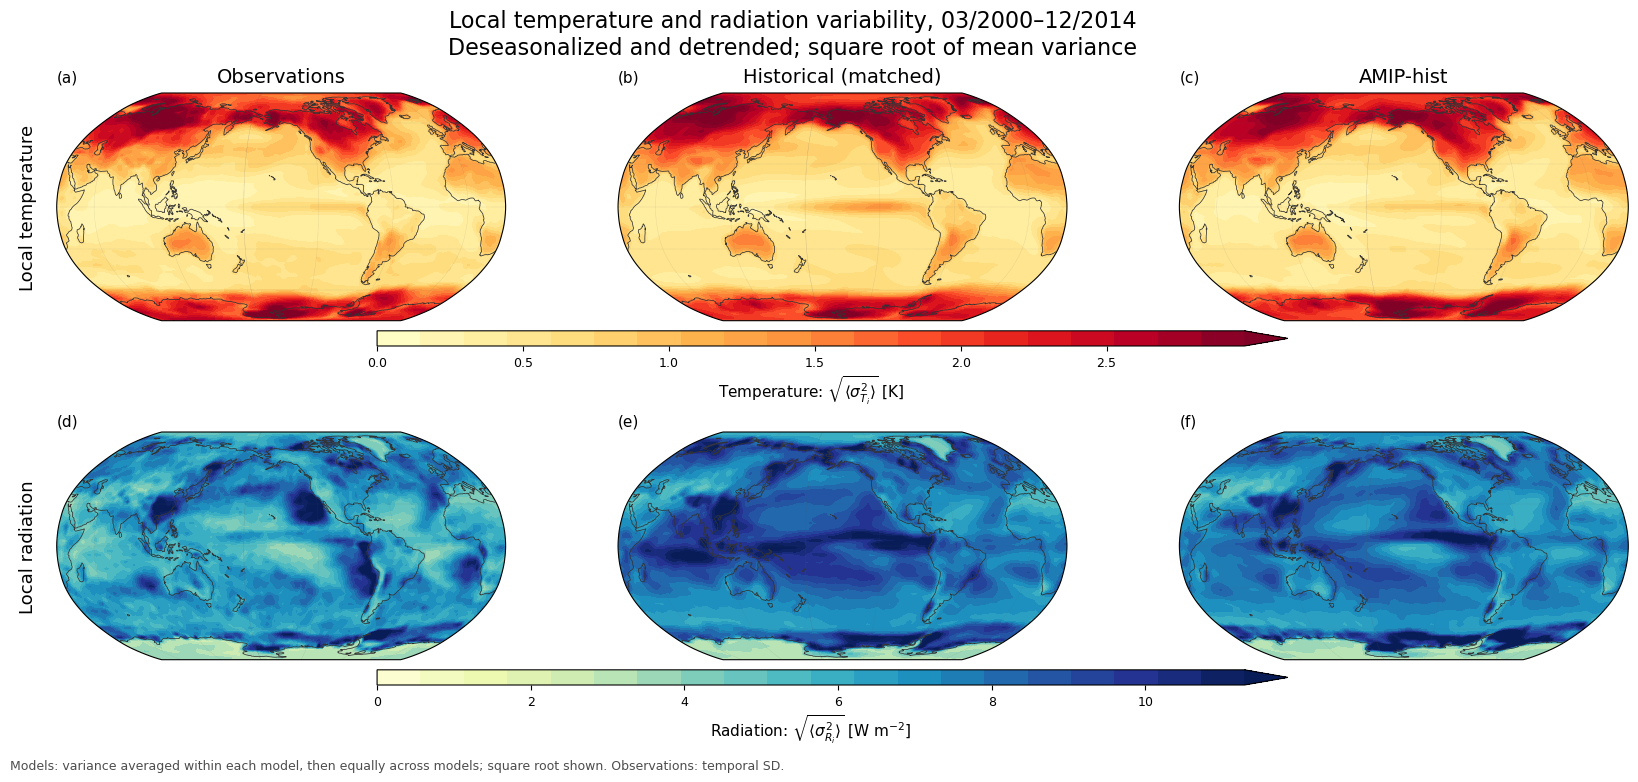

In [6]:
# %% 4. Make the two-row observation / historical / AMIP figure
# Both local temperature and radiation are from the detrended overlap archive.
# These are absolute variability maps, not model-minus-observation bias maps.
# The square-root display has units K and W m^-2, not their squared variance units.
fig_variability_grid, axes_variability_grid = plot_2x3_variability_maps(
    maps=variability_grid_maps, lat=variability_lat, lon=variability_lon,
    row_titles=["Local temperature", "Local radiation"],
    column_titles=["Observations", "Historical (matched)", "AMIP-hist"],
    figure_title="Local temperature and radiation variability, 03/2000–12/2014\n"
                 "Deseasonalized and detrended; square root of mean variance",
    colorbar_labels=[r"Temperature: $\sqrt{\langle\sigma_{T_i}^{2}\rangle}$ [K]",
                     r"Radiation: $\sqrt{\langle\sigma_{R_i}^{2}\rangle}$ [W m$^{-2}$]"],
    central_longitude=210, cmaps=["YlOrRd", "YlGnBu"],
    vmaxs=[None, None], robust_percentile=98, number_of_levels=21, plot_method="contourf",
    robust_masks=None,             # No variance-specific robustness masks calculated yet.
    # vmaxs=[1.5, 15.],            # Instead set your chosen T and R upper limits above.
    # savepath="/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/tas_var/variability_grid_rms_std.png",
)
plt.show()

# Useful arrays to inspect after plotting:
# variability_model_mean_variance["historical_matched"]["T"]  -> (model, lat, lon), K^2
# variability_MMM_variance["amip_hist"]["R"]                   -> (lat, lon), (W m^-2)^2
# variability_MMM_rms_std["amip_hist"]["R"]                    -> (lat, lon), W m^-2
# variability_MMM_n_models["historical_matched"]["T"]           -> model count at each grid cell


In [15]:
import xarray as xr

filepath_mask    = '/scratch/leiff/MCA/data/IMERG_land_sea_mask_g025.nc'
mask = xc.open_dataset(filepath_mask)
mask['split_50'] = xr.where(mask['landseamask'] > 50, 1, np.nan)
mask['land_50'] = xr.where(mask['landseamask'] <= 50, 1, np.nan)

# Source convention: 1 = land, NaN = ocean.
mask_land = np.asarray(mask["land_50"].data, dtype=float)
land_mask = mask_land == 1
ocean_mask = np.isnan(mask_land)

# Mask all six panels without changing the original maps.
variability_land_maps = np.where(land_mask[None, None, :, :], variability_grid_maps, np.nan)
variability_ocean_maps = np.where(ocean_mask[None, None, :, :], variability_grid_maps, np.nan)


# Latitude mask broadcasts across longitude; True means retain the cell.
within_60 = (np.abs(np.asarray(variability_lat)) <= 60)[:, None]
land_mask_60 = land_mask & within_60
ocean_mask_60 = ocean_mask & within_60

# Apply to every panel, preserving the original and full-latitude maps.
variability_land_maps_60 = np.where(land_mask_60[None, None, :, :], variability_grid_maps, np.nan)
variability_ocean_maps_60 = np.where(ocean_mask_60[None, None, :, :], variability_grid_maps, np.nan)

2026-09-15 15:54:05,277 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."


Saved: /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/tas_var/variability_grid_rms_std_ocean.png


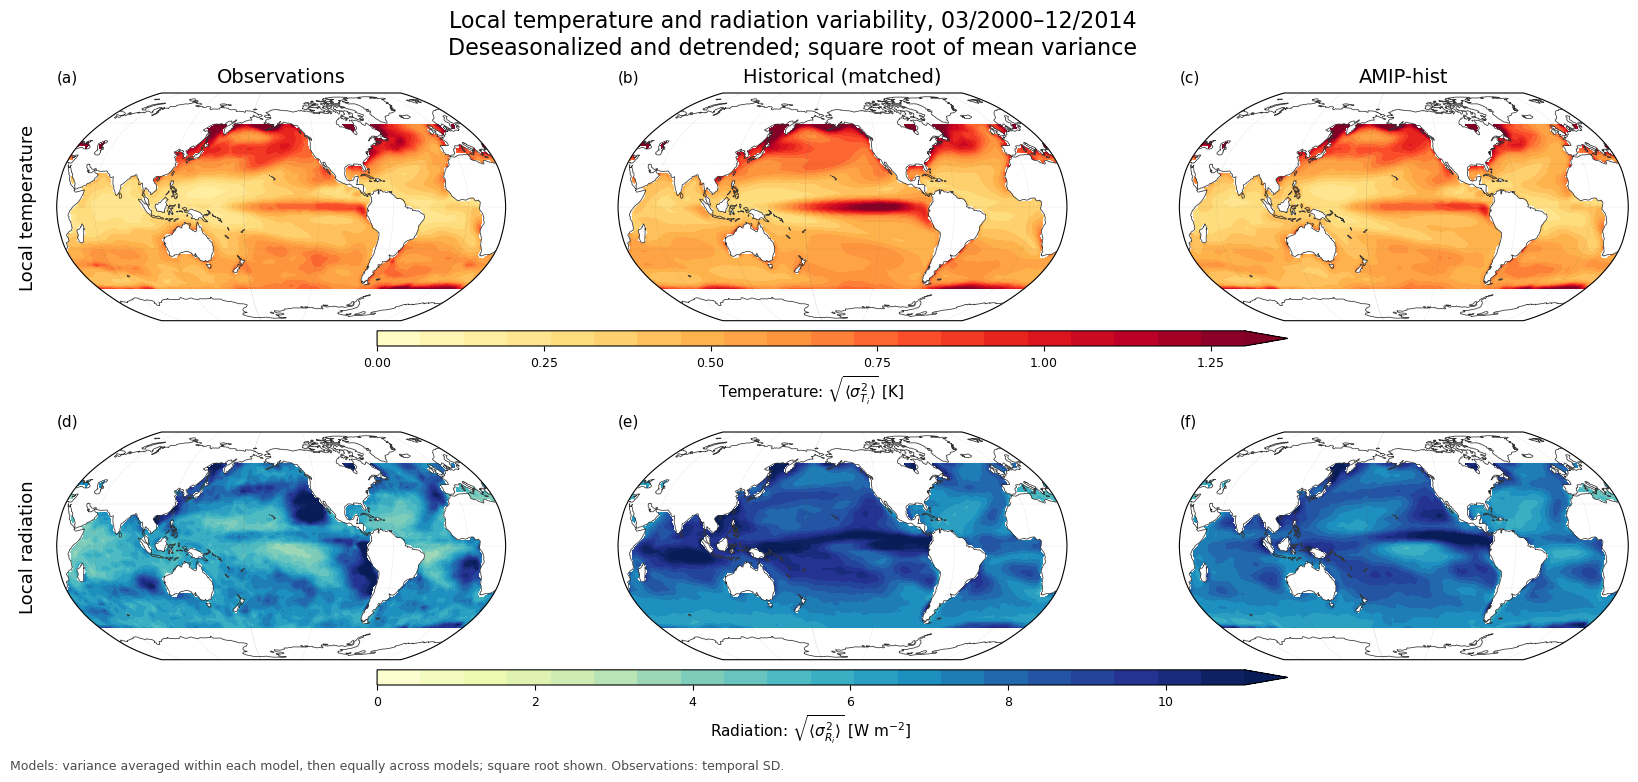

In [18]:
# %% 4. Make the two-row observation / historical / AMIP figure
# Both local temperature and radiation are from the detrended overlap archive.
# These are absolute variability maps, not model-minus-observation bias maps.
# The square-root display has units K and W m^-2, not their squared variance units.
fig_variability_grid, axes_variability_grid = plot_2x3_variability_maps(
    maps=variability_ocean_maps_60, lat=variability_lat, lon=variability_lon,
    row_titles=["Local temperature", "Local radiation"],
    column_titles=["Observations", "Historical (matched)", "AMIP-hist"],
    figure_title="Local temperature and radiation variability, 03/2000–12/2014\n"
                 "Deseasonalized and detrended; square root of mean variance",
    colorbar_labels=[r"Temperature: $\sqrt{\langle\sigma_{T_i}^{2}\rangle}$ [K]",
                     r"Radiation: $\sqrt{\langle\sigma_{R_i}^{2}\rangle}$ [W m$^{-2}$]"],
    central_longitude=210, cmaps=["YlOrRd", "YlGnBu"],
    vmaxs=[None, None], robust_percentile=98, number_of_levels=21, plot_method="contourf",
    robust_masks=None,             # No variance-specific robustness masks calculated yet.
    # vmaxs=[1.5, 15.],            # Instead set your chosen T and R upper limits above.
    savepath="/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/tas_var/variability_grid_rms_std_ocean.png",
)
plt.show()



In [6]:
scores = np.load('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/member_scores.npy', allow_pickle=True).item()

In [8]:
overlap_member_values

{'amip_hist': {'corr_Ti_Ri': {'BCC-CSM2-MR': array([[[-0.62641097, -0.63427498, -0.64000646, ..., -0.60537688,
            -0.6132859 , -0.61996025],
           [-0.64234654, -0.65439143, -0.66605926, ..., -0.5985261 ,
            -0.61436947, -0.62880919],
           [-0.59157604, -0.61190776, -0.63258436, ..., -0.50970063,
            -0.54119368, -0.56761855],
           ...,
           [-0.30848687, -0.27961015, -0.27521127, ..., -0.2030662 ,
            -0.2346697 , -0.24733592],
           [-0.22864888, -0.19759797, -0.21293156, ..., -0.15593956,
            -0.15390737, -0.20920051],
           [-0.25789537, -0.24595762, -0.24264768, ..., -0.24830514,
            -0.24865034, -0.26516824]]], shape=(1, 72, 144)),
   'CAMS-CSM1-0': array([[[-0.88328517, -0.88074933, -0.88461558, ..., -0.88126893,
            -0.88455424, -0.8892592 ],
           [-0.86509692, -0.86273983, -0.86252579, ..., -0.85912449,
            -0.85479725, -0.85842231],
           [-0.86551801, -0.86520464, -0